In [5]:
print("Hello world")

Hello world


In [6]:
%pip install numpy scipy pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install matplotlib tabulate

Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [9]:
import numpy as np
import pandas as pd

from scipy import stats
from scipy.io import loadmat
from sklearn.preprocessing import minmax_scale
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, roc_auc_score
from tabulate import tabulate
from matplotlib import pyplot as plt

In [10]:
def gaussian(x, mean = 0, stdev = 1):
    # Change type of x to be numpy array

    if type(x) != np.array:
        x = np.array(x)
    
    f_x = np.multiply(
        np.divide(1, np.multiply(stdev, np.sqrt(2 * np.pi))),
        np.exp(np.multiply(-0.5, np.square(np.divide(x - mean, stdev))))
    )

    return f_x

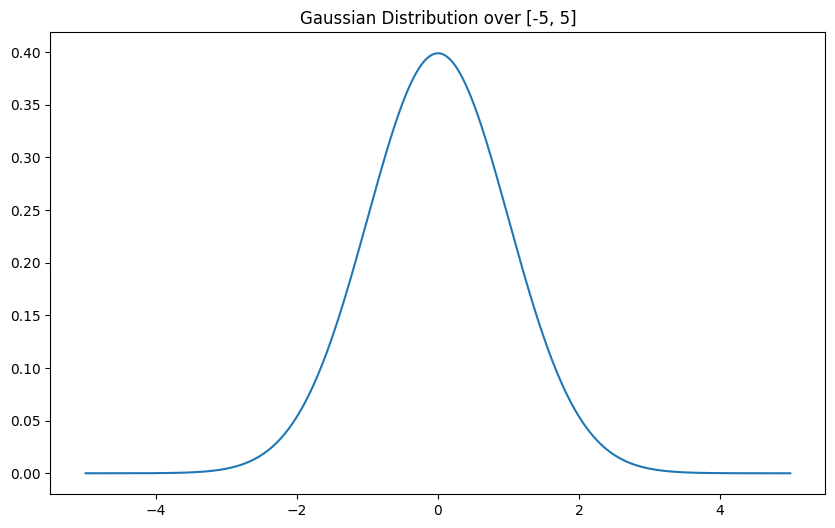

In [11]:
x = np.linspace(-5, 5, num = 1000)

plt.figure(figsize = (10, 6))
plt.plot(x, gaussian(x, 0, 1))
plt.title("Gaussian Distribution over [-5, 5]")
plt.show()

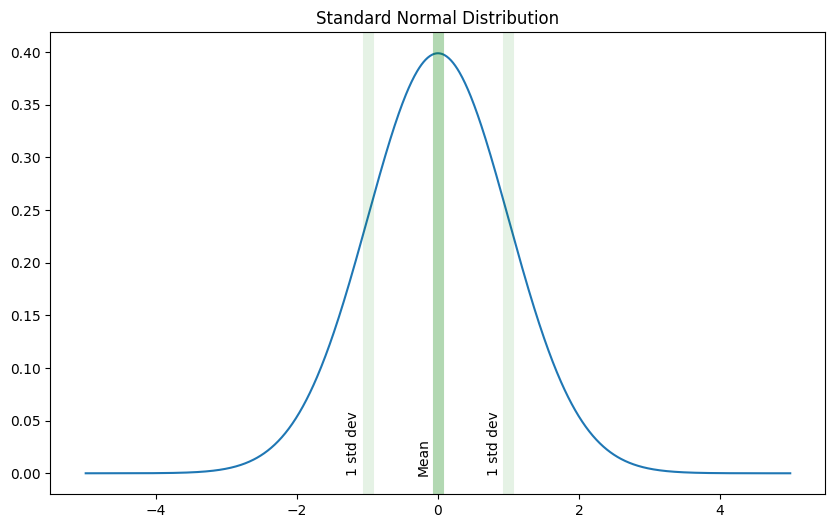

In [12]:
## Using scipy.stats for the same thing as above
x = np.linspace(-5, 5, num = 1000)


plt.figure(figsize = (10, 6))
plt.plot(x, stats.norm(0, 1).pdf(x))

plt.axvline(0, c = 'green', alpha = 0.3, lw = 8)
plt.annotate("Mean", (-0.3, 0), rotation = 90)

plt.axvline(1, c = 'green', alpha = 0.1, lw = 8)
plt.annotate("1 std dev", (0.7, 0), rotation = 90)


plt.axvline(-1, c = 'green', alpha = 0.1, lw = 8)
plt.annotate("1 std dev", (-1.3, 0), rotation = 90)

plt.title("Standard Normal Distribution")
plt.show()

In [13]:
x1 = np.concatenate([np.random.normal(10, 5, size = 100)])
x2 = np.concatenate([np.random.normal(18, 2, size = 100)])


means = np.mean([x1, x2], axis = 1)
stdevs = np.std([x1, x2], axis = 1)

dist = stats.multivariate_normal(means, stdevs)


x1 = np.append(x1, [1, 1.5, 20, 21, 19])
x2 = np.append(x2, [25, 3, 2.1, 7, 3])

proba = dist.pdf(np.array([x1, x2]).T)

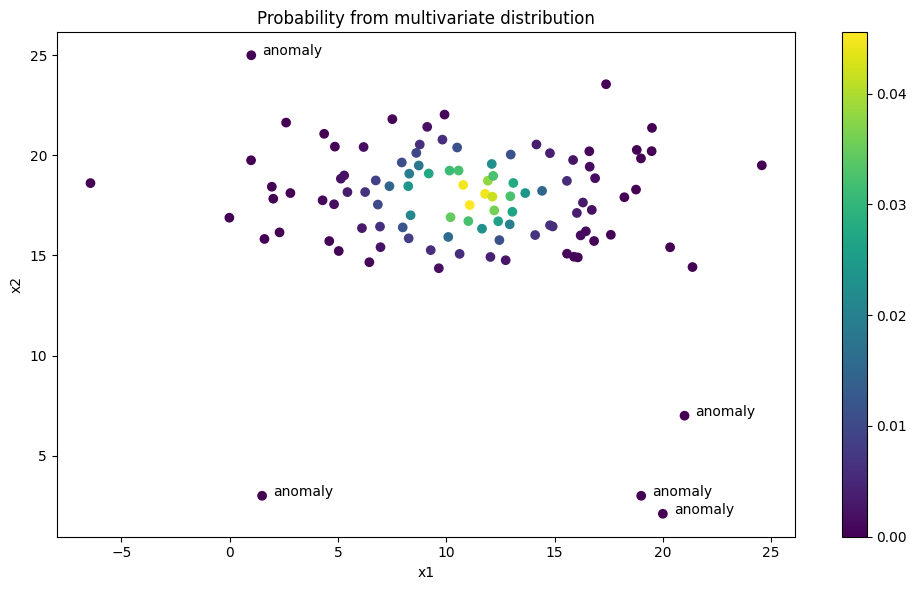

In [14]:
plt.figure(figsize = (10, 6))
plt.scatter(x1, x2, c = proba)
plt.title("Probability from multivariate distribution")
plt.xlabel("x1")
plt.ylabel("x2")
for i in range(5):
    plt.annotate("anomaly", (x1[-(i + 1)] + 0.5, x2[-(i + 1)]))

plt.colorbar()
plt.tight_layout()
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_10057/343639893.py:5: SyntaxWarning: invalid escape sequence '\e'
  ax1.title.set_text(f"Identified anomalies given $\epsilon = {eps}$")
/tmp/ipykernel_10057/343639893.py:11: SyntaxWarning: invalid escape sequence '\e'
  ax2.title.set_text(f"Identified anomalies given $\epsilon = {eps}$")


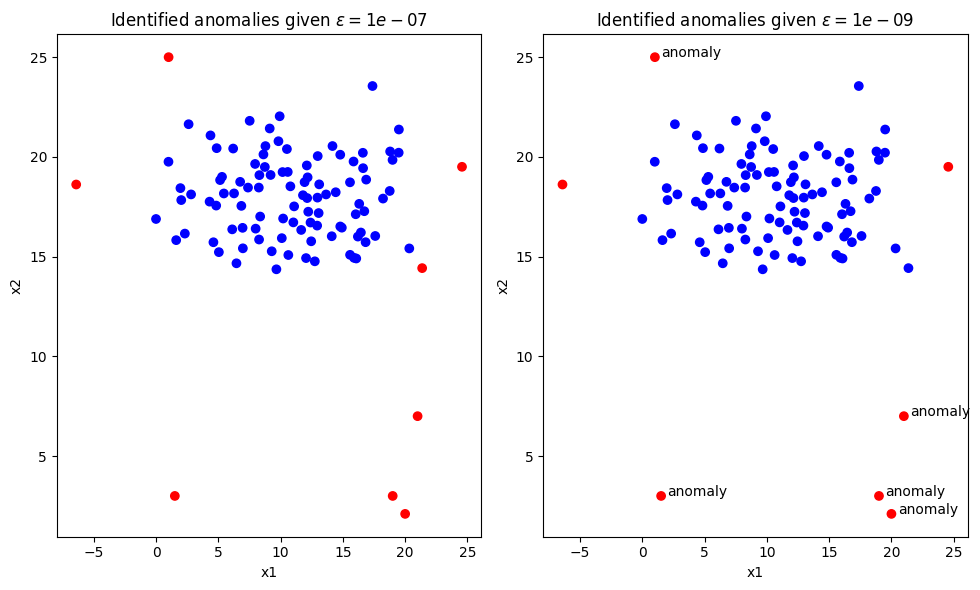

In [15]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 6))

eps = 1e-7
ax1.scatter(x1, x2, c = np.where(proba < eps, "red", "blue"))
ax1.title.set_text(f"Identified anomalies given $\epsilon = {eps}$")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")

eps = 1e-9
ax2.scatter(x1, x2, c = np.where(proba < eps, "red", "blue"))
ax2.title.set_text(f"Identified anomalies given $\epsilon = {eps}$")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")

for i in range(5):
    plt.annotate("anomaly", (x1[-(i + 1)] + 0.5, x2[-(i + 1)]))
plt.tight_layout()
plt.show()

### From now, real datasets are used to classify

In [22]:
df = pd.read_csv('data/wine/wine.data')

cols = ['class', 'alcohol', 'malicacid', 'ash', 'alkalinity_of_ash', 'magnesium',
        'total_phenols', 'flavanoids', 'nonflanoid_phenols', 'proanthocyanins',
        'color_intensity', 'hue', '0D280_0D315_of_diluted_winws', 'proline']

df.columns = cols

y_true = np.where(df['class'] == 3, 1, 0)

features = [c for c in df.columns if c != 'class' and stats.shapiro(df[c]).pvalue >= 0.01]

# anomaly targets
# y_true = wine["y"].flatten()

# include features that follow a normal distribution
# this is tested using the Shapiro-Wilk test for normality
# features = [c for c in columns if stats.shapiro(df[c]).pvalue >= 0.01] 

# log scale columns to normalize them
for c in ['total_phenols', 'proanthocyanins', 'color_intensity', 'hue']:
    df[c] = np.log(df[c]+1)
    features.append(c)

# identify outliers and exclude them from the training set
df['outlier'] = 0
for f in features:
    df['outlier'] += ((df[f] > df[f].mean()+2*df[f].std()) | (df[f] < df[f].mean() - 2*df[f].std())).astype(int)

df_train = df[df['outlier']==0]

# create a multivariate distribution given our means and standard deviations
dist = stats.multivariate_normal(df_train[features].mean().to_numpy(), df_train[features].std().to_numpy())

# calculate probability density values for our features for ALL values
proba = dist.pdf(df[features].to_numpy())

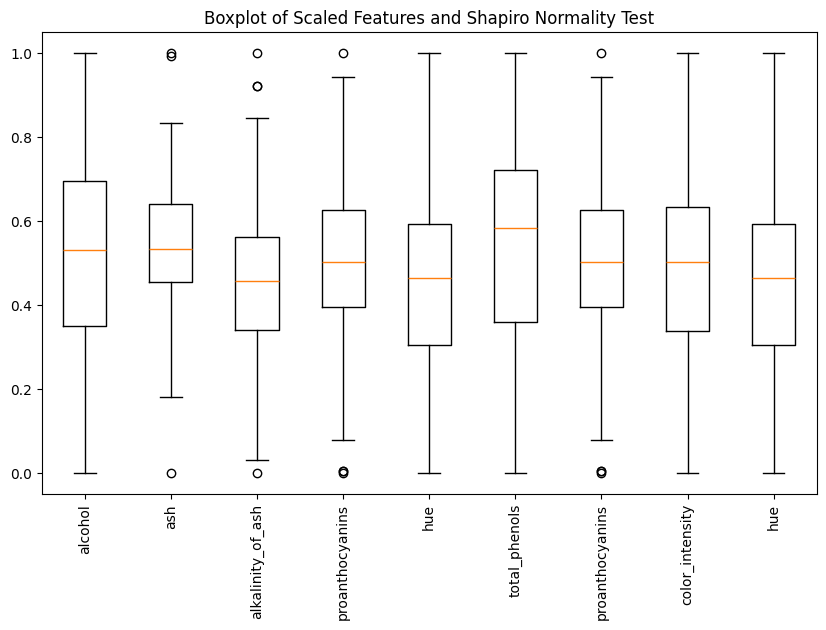

In [23]:
plt.figure(figsize=(10, 6))
plt.boxplot(minmax_scale(df[features]))
plt.xticks(ticks=list(range(1, len(features)+1)), labels=features, rotation=90)
plt.title("Boxplot of Scaled Features and Shapiro Normality Test")
plt.show()

In [24]:
# evaluate the model with different epsilon values

eps = np.linspace(0.001, 0.01, 21)
recall = []
precision = []
auc = []

for e in eps:
    y_pred = np.where(proba < e, 1, 0)
    recall.append(recall_score(y_true, y_pred))
    precision.append(precision_score(y_true, y_pred))
    auc.append(roc_auc_score(y_true, y_pred))

<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_10057/2500483374.py:6: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Comparison of evaluation metrics by $\epsilon$ value')


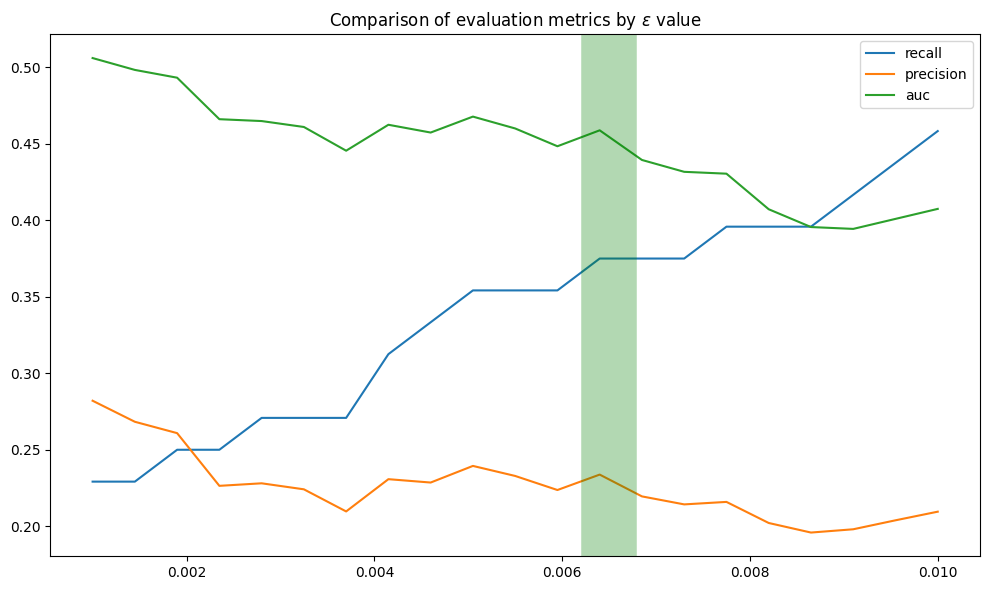

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(eps, recall, label='recall')
plt.plot(eps, precision, label='precision')
plt.plot(eps, auc, label='auc')
plt.axvline(0.0065, c='green', alpha=0.3, lw=40)
plt.title('Comparison of evaluation metrics by $\epsilon$ value')
plt.legend()
plt.tight_layout()
plt.show()